# Matching Pennies — entrega

Notebook de la entrega: corre los experimentos en MP con FP, RM y RandomAgent (implementaciones del equipo, en `agents/`), persiste `history` dicts en `data/mp/`, guarda figuras en `images/mp/`, y registra el progreso en `logs/mp/MP.log`.

Las gráficas usan los helpers de `utils.plots` (compartidos por todos los notebooks del equipo).

## Setup

In [1]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Agentes del equipo
from games.mp import MP
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching
from agents.random_agent import RandomAgent

# Infraestructura compartida (utils/)
from utils.logger import get_logger
from utils.storage import cached, savefig
from utils.plots import (
    plot_policy_evolution,
    plot_distance_to_nash,
    plot_cumulative_average_reward,
    plot_cumulative_regret,
    plot_average_positive_regret,
    plot_instantaneous_vs_average_policy,
)

# Helper para ejecutar y cachear corridas (importado desde utils/experiments.py)
from utils import experiments as exp

log = get_logger(notebook_name='MP')

# Constantes del experimento
ITERATIONS = 5000
MAX_ITER = 1000   # cap visual para las figuras (todas slicean a este horizonte)
NASH = np.array([0.5, 0.5])
LABELS = ['H', 'T']

log.info('Setup MP listo')

2026-05-24 19:25:30 | INFO    | Setup MP listo


## FictitiousPlay vs FictitiousPlay

Deberían converger al equilibrio de Nash mixto $(0.5, 0.5)$. FP es greedy contra la creencia empírica del oponente, así que las primeras rondas pueden mostrar oscilaciones (ráfagas de la misma acción) hasta que las frecuencias acumuladas se estabilizan.

In [25]:
log.info('FP vs FP en MP — iniciando experimento')

# `initial` es dict[agent_id → ndarray]: conteo inicial de las acciones de cada
# OPONENTE. Cada FP ignora la entrada de su propio agente y usa la del rival.
fp_initial = {'agent_0': np.array([1, 1]), 'agent_1': np.array([1, 1])}
agent_pair_fp = [
    (FictitiousPlay, {'initial': fp_initial}),
    (FictitiousPlay, {'initial': fp_initial}),
]
history_fp = exp.cached_run('mp_history_fp_vs_fp', MP(), agent_pair_fp,
                              iterations=ITERATIONS, seed=1)

log.info(f'FP vs FP: política final agent_0={history_fp["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp["policy_history"]["agent_1"][-1].round(3)}')

2026-05-23 18:21:34 | INFO    | FP vs FP en MP — iniciando experimento
2026-05-23 18:21:34 | INFO    | FP vs FP: política final agent_0=[0.503 0.497], agent_1=[0.507 0.493]


### Evolución de la política

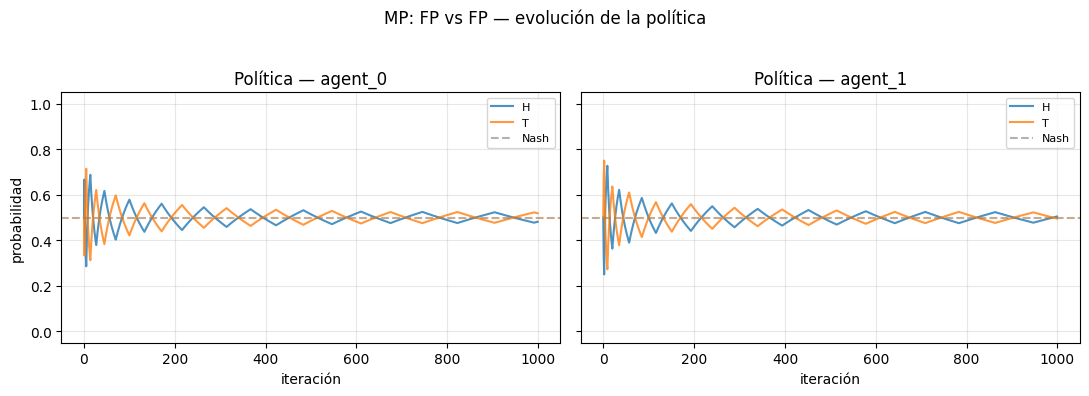

In [26]:
plot_policy_evolution(history_fp, action_labels=LABELS, nash=NASH,
                       title='MP: FP vs FP — evolución de la política',
                       save='mp/policy_evolution_fp_vs_fp', max_iter=MAX_ITER)
plt.show()

### Distancia al Nash mixto

Debería tender a 0.

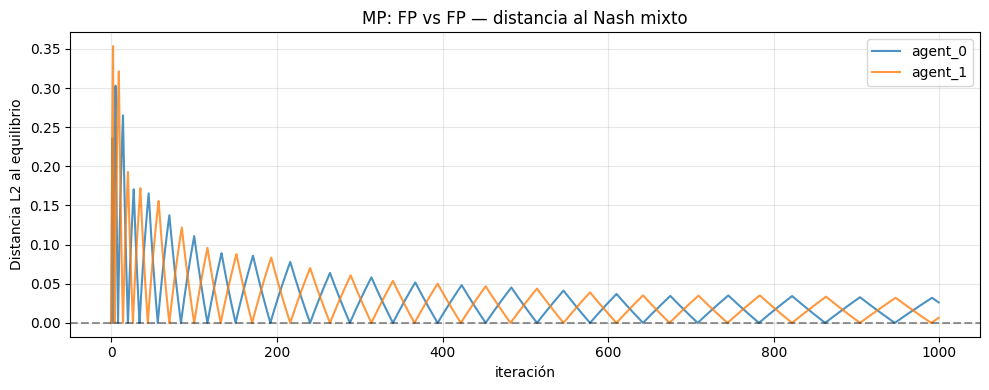

In [27]:
plot_distance_to_nash(history_fp, nash=NASH, max_iter=MAX_ITER,
                       title='MP: FP vs FP — distancia al Nash mixto',
                       save='mp/distance_to_nash_fp_vs_fp')
plt.show()

### Reward promedio acumulado

Valor del juego = 0 en equilibrio.

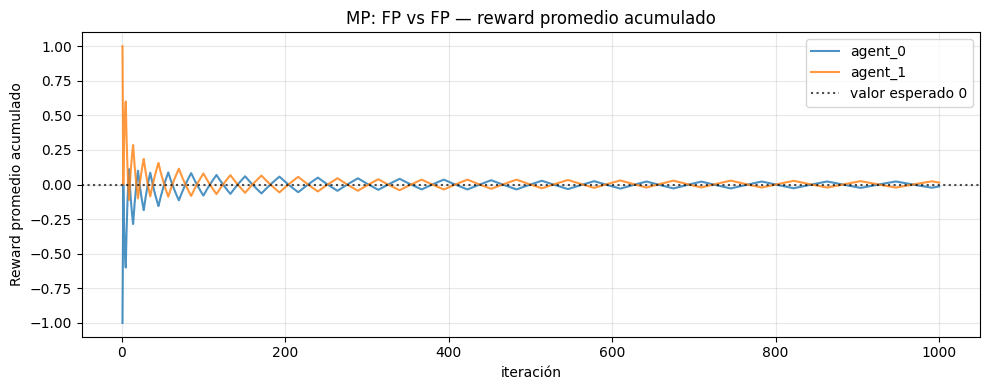

In [28]:
plot_cumulative_average_reward(history_fp, expected_value=0, max_iter=MAX_ITER,
                                title='MP: FP vs FP — reward promedio acumulado',
                                save='mp/reward_cum_avg_fp_vs_fp')
plt.show()

## RegretMatching vs RegretMatching

A diferencia de FP, RM no juega greedy sino que muestrea según los regrets positivos acumulados. La política instantánea (`curr_policy`) puede oscilar fuerte pero el **promedio temporal** (`learned_policy`) converge al equilibrio.

In [29]:
log.info('RM vs RM en MP — iniciando experimento')

agent_pair_rm = [(RegretMatching, {}), (RegretMatching, {})]
history_rm = exp.cached_run('mp_history_rm_vs_rm', MP(), agent_pair_rm,
                              iterations=ITERATIONS, seed=1)

log.info(f'RM vs RM: política promedio final agent_0={history_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-23 18:21:35 | INFO    | RM vs RM en MP — iniciando experimento
2026-05-23 18:21:35 | INFO    | RM vs RM: política promedio final agent_0=[0.485 0.515], agent_1=[0.505 0.495]


### Política promedio aprendida

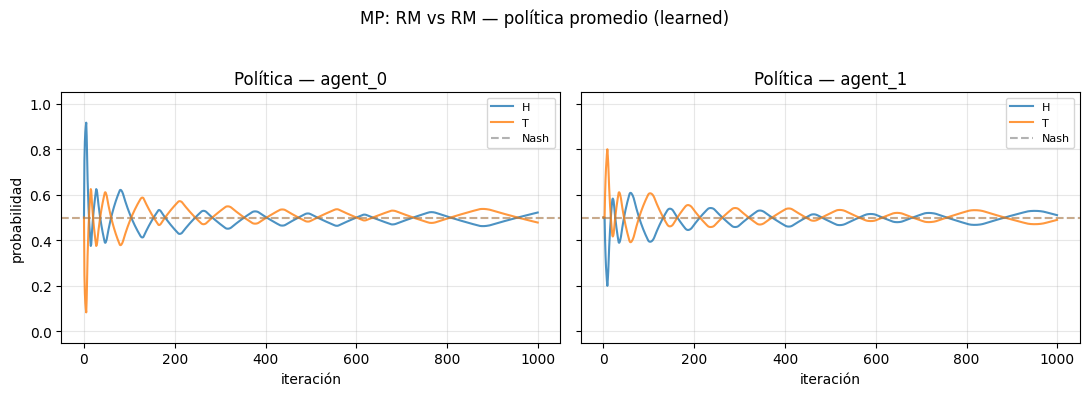

In [30]:
plot_policy_evolution(history_rm, action_labels=LABELS, nash=NASH,
                       title='MP: RM vs RM — política promedio (learned)',
                       save='mp/policy_evolution_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

### Distancia al equilibrio

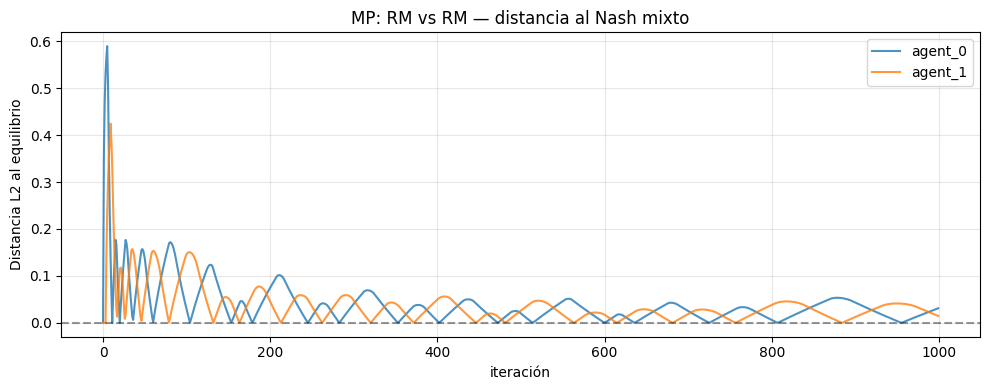

In [31]:
plot_distance_to_nash(history_rm, nash=NASH, max_iter=MAX_ITER,
                       title='MP: RM vs RM — distancia al Nash mixto',
                       save='mp/distance_to_nash_rm_vs_rm')
plt.show()

### Reward promedio acumulado

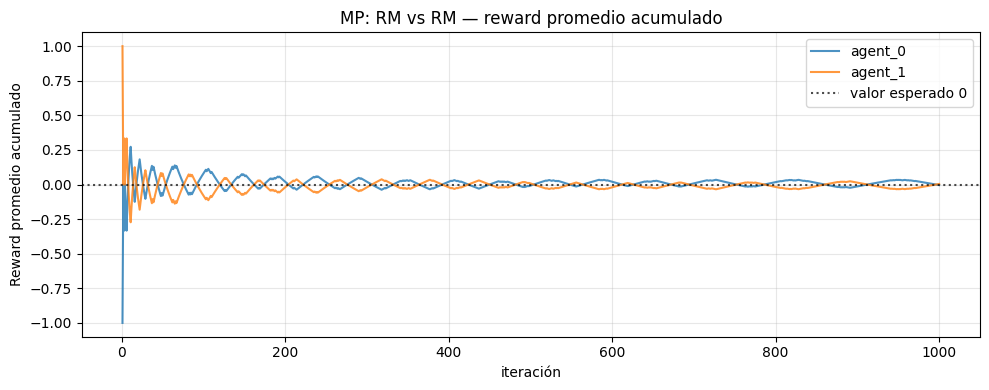

In [32]:
plot_cumulative_average_reward(history_rm, expected_value=0, max_iter=MAX_ITER,
                                title='MP: RM vs RM — reward promedio acumulado',
                                save='mp/reward_cum_avg_rm_vs_rm')
plt.show()

### Regrets acumulados

Deberían oscilar entre positivos y negativos según qué acción habría sido mejor en cada ronda.

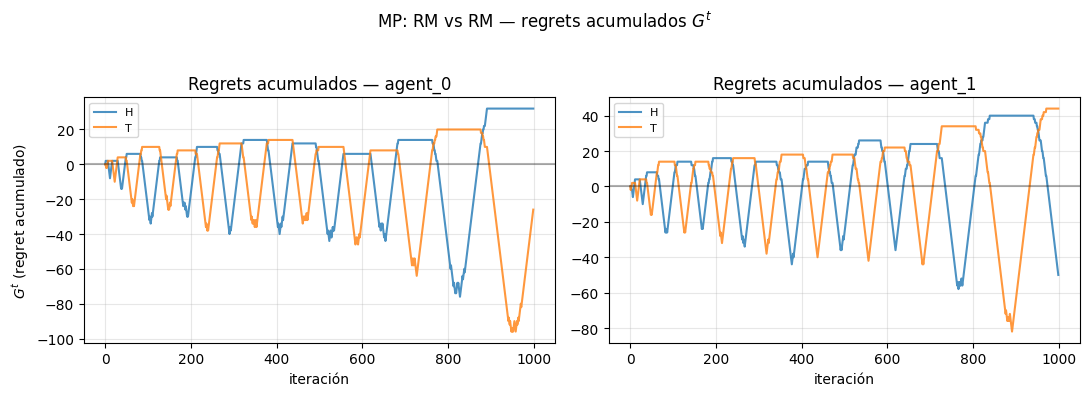

In [33]:
plot_cumulative_regret(history_rm, action_labels=LABELS,
                        title='MP: RM vs RM — regrets acumulados $G^t$',
                        save='mp/cum_regrets_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

### Regret promedio positivo / t

Validación de la garantía no-regret de Hart & Mas-Colell: debe tender a 0.

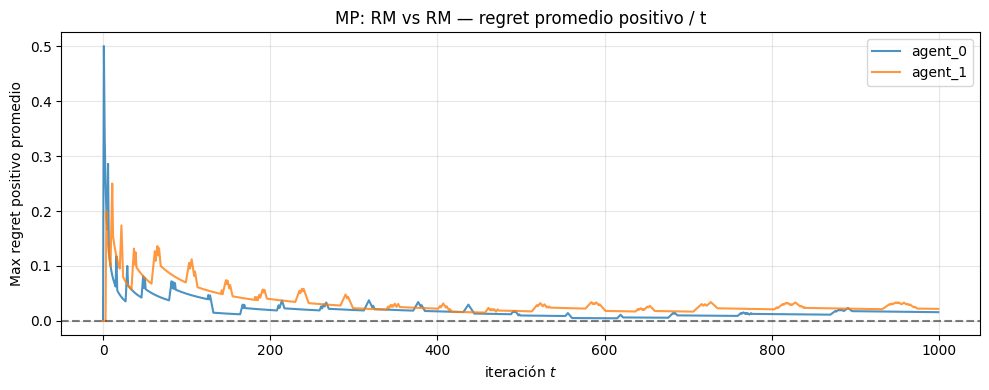

In [34]:
plot_average_positive_regret(history_rm,
                              title='MP: RM vs RM — regret promedio positivo / t',
                              save='mp/avg_positive_regret_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

## FictitiousPlay vs RegretMatching

Se espera que ambos terminen cerca de $(0.5, 0.5)$ pero con trayectorias y oscilaciones distintas. FP responde greedy a la creencia empírica, RM muestrea según regrets. La gráfica de **política instantánea vs promedio** del RM ilustra el concepto: aunque `curr_policy` oscile, `learned_policy` converge.

In [35]:
log.info('FP vs RM en MP — iniciando experimento')

fp_initial = {'agent_0': np.array([1, 1]), 'agent_1': np.array([1, 1])}
agent_pair_fp_rm = [
    (FictitiousPlay, {'initial': fp_initial}),
    (RegretMatching, {}),
]
history_fp_rm = exp.cached_run('mp_history_fp_vs_rm', MP(), agent_pair_fp_rm,
                                 iterations=ITERATIONS, seed=1)

log.info(f'FP vs RM: política final agent_0={history_fp_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-23 18:21:36 | INFO    | FP vs RM en MP — iniciando experimento
2026-05-23 18:21:36 | INFO    | FP vs RM: política final agent_0=[0.513 0.487], agent_1=[0.499 0.501]


### Políticas aprendidas (FP empírica + RM promedio)

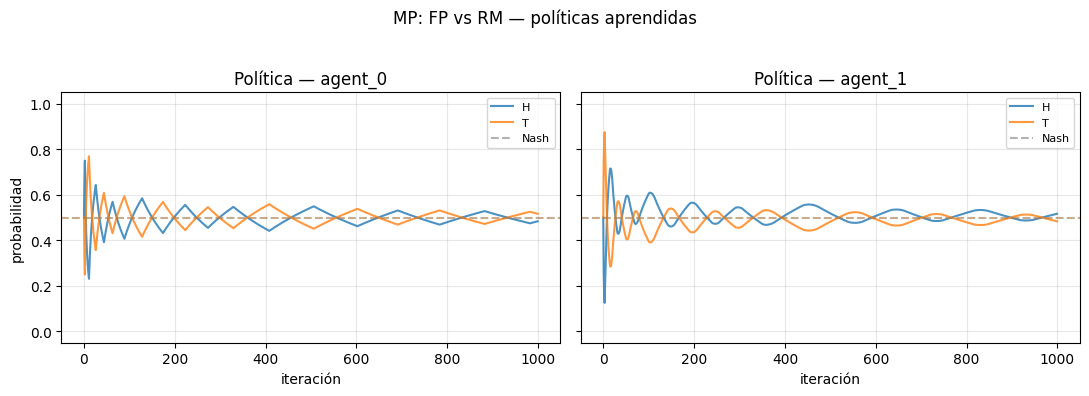

In [36]:
plot_policy_evolution(history_fp_rm, action_labels=LABELS, nash=NASH,
                       title='MP: FP vs RM — políticas aprendidas',
                       save='mp/policy_evolution_fp_vs_rm', max_iter=MAX_ITER)
plt.show()

### Distancia al equilibrio + reward acumulado

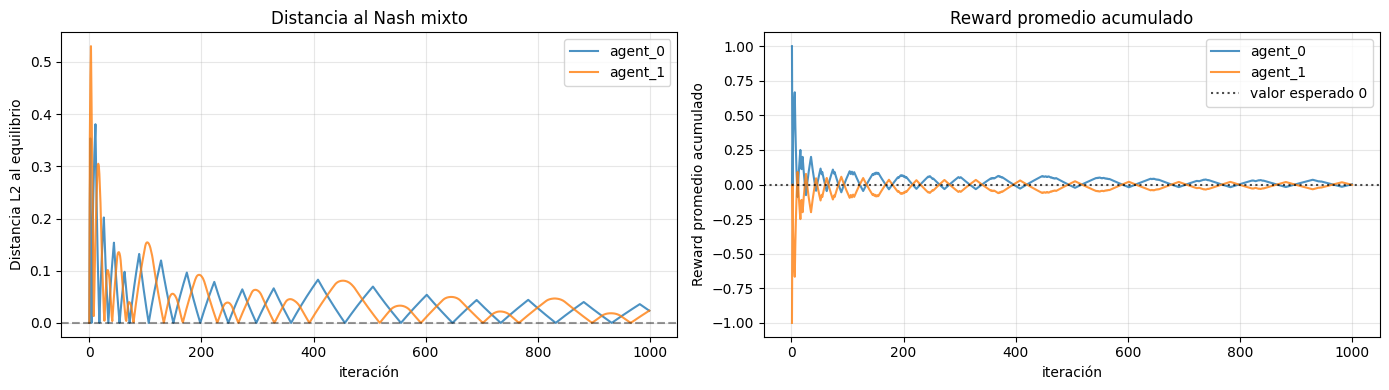

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_fp_rm, nash=NASH, max_iter=MAX_ITER,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_fp_rm, expected_value=0, max_iter=MAX_ITER,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('mp/distance_and_reward_fp_vs_rm')
plt.show()

### RM: política instantánea vs promedio temporal

La instantánea (`curr_policy`) oscila; la promedio (`learned_policy`) converge.

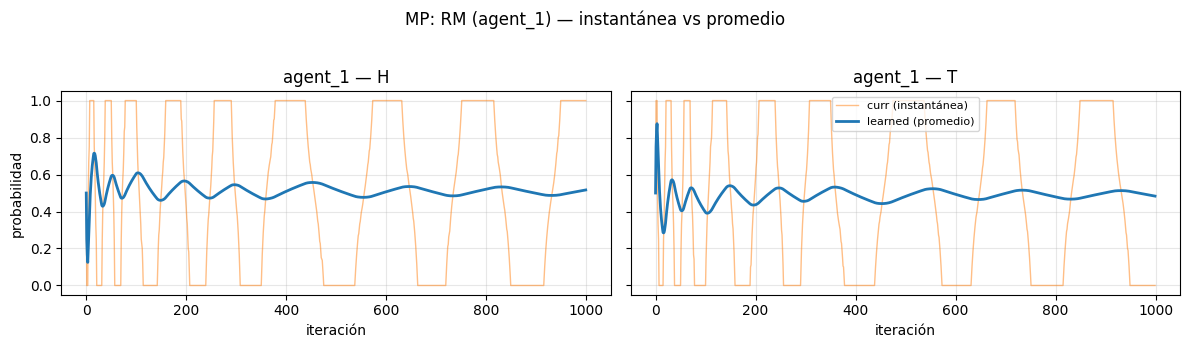

In [38]:
# Sólo aplica al agente RM (agent_1 en este pair)
plot_instantaneous_vs_average_policy(history_fp_rm, action_labels=LABELS,
                                       agent='agent_1',
                                       title='MP: RM (agent_1) — instantánea vs promedio',
                                       save='mp/curr_vs_avg_policy_rm_in_fp_vs_rm', max_iter=MAX_ITER)
plt.show()

## FictitiousPlay vs RandomAgent

RandomAgent juega la política uniforme fija, que en Matching Pennies coincide con el equilibrio mixto. Por eso FP no debería poder explotarlo de forma sostenida: la política empírica debería mantenerse cerca de $(0.5, 0.5)$ y el reward promedio acumulado debería tender a 0.


In [2]:
log.info('FP vs Random en MP — iniciando experimento')

fp_initial = {'agent_0': np.array([1, 1]), 'agent_1': np.array([1, 1])}
agent_pair_fp_random = [
    (FictitiousPlay, {'initial': fp_initial}),
    (RandomAgent, {}),
]
history_fp_random = exp.cached_run('mp_history_fp_vs_random', MP(), agent_pair_fp_random,
                                   iterations=ITERATIONS, seed=1)

log.info(f'FP vs Random: política final agent_0={history_fp_random["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp_random["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 19:26:02 | INFO    | FP vs Random en MP — iniciando experimento
2026-05-24 19:26:02 | INFO    | FP vs Random: política final agent_0=[1. 0.], agent_1=[0.5 0.5]


### Políticas aprendidas / reportadas

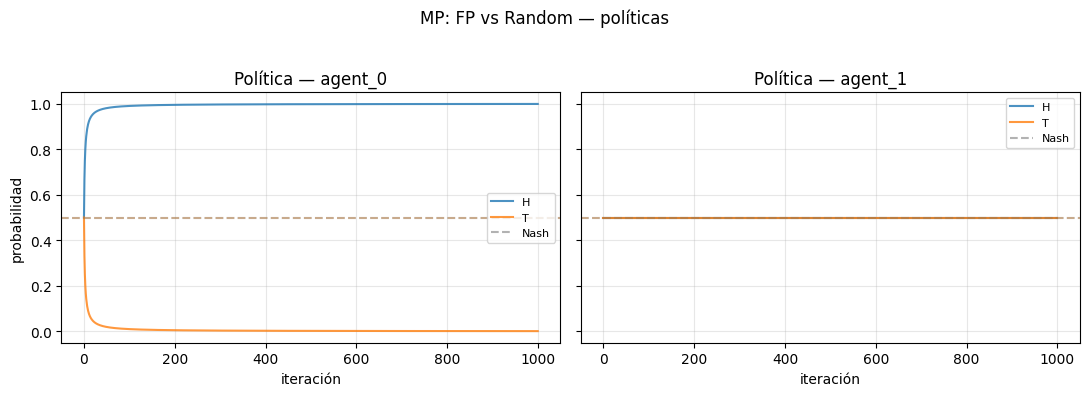

In [3]:
plot_policy_evolution(history_fp_random, action_labels=LABELS, nash=NASH,
                       title='MP: FP vs Random — políticas',
                       save='mp/policy_evolution_fp_vs_random', max_iter=MAX_ITER)
plt.show()

### Distancia al equilibrio + reward acumulado

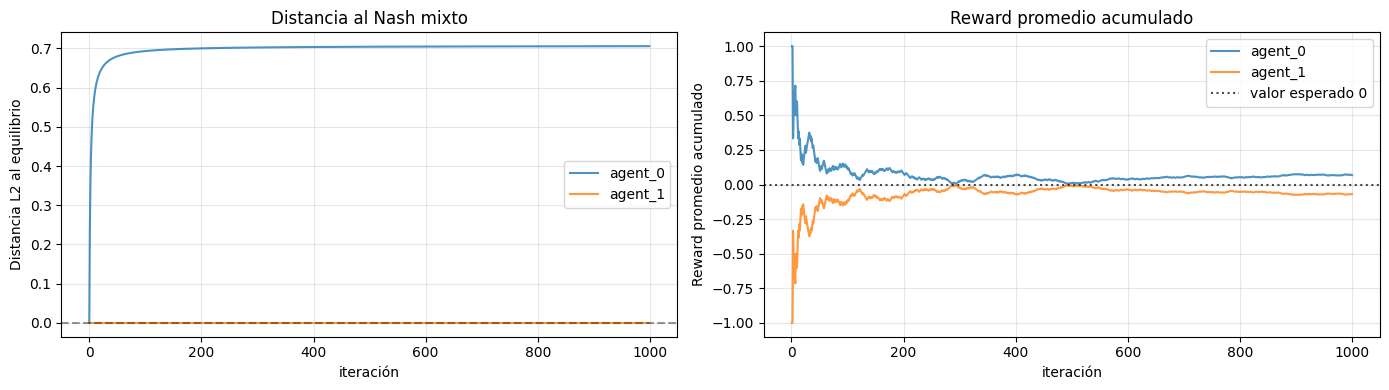

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_fp_random, nash=NASH, max_iter=MAX_ITER,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_fp_random, expected_value=0, max_iter=MAX_ITER,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('mp/distance_and_reward_fp_vs_random')
plt.show()

## RegretMatching vs RandomAgent

RandomAgent vuelve a jugar uniforme fijo. RM debería aprender una política promedio cercana a $(0.5, 0.5)$, con regret positivo promedio bajo y reward acumulado promedio cercano a 0.


In [5]:
log.info('RM vs Random en MP — iniciando experimento')

agent_pair_rm_random = [
    (RegretMatching, {}),
    (RandomAgent, {}),
]
history_rm_random = exp.cached_run('mp_history_rm_vs_random', MP(), agent_pair_rm_random,
                                   iterations=ITERATIONS, seed=1)

log.info(f'RM vs Random: política final agent_0={history_rm_random["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_rm_random["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 19:26:35 | INFO    | RM vs Random en MP — iniciando experimento
2026-05-24 19:26:35 | INFO    | RM vs Random: política final agent_0=[1. 0.], agent_1=[0.5 0.5]


### Política promedio aprendida / reportada

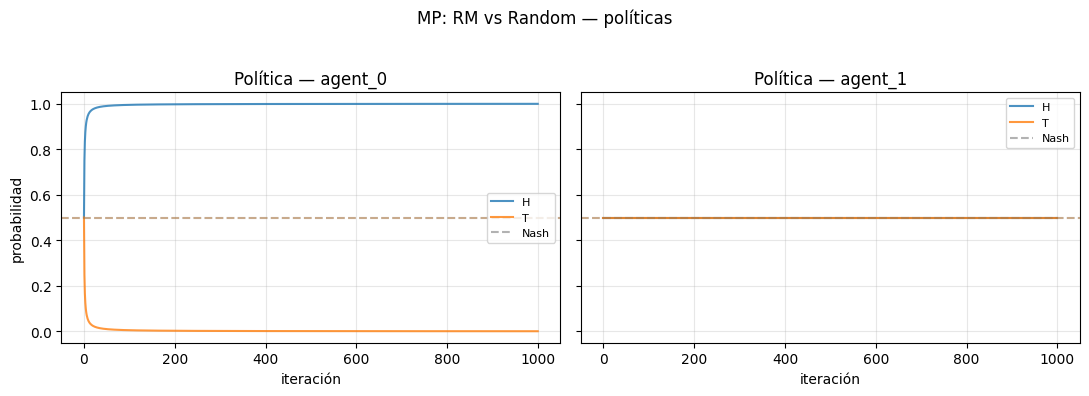

In [6]:
plot_policy_evolution(history_rm_random, action_labels=LABELS, nash=NASH,
                       title='MP: RM vs Random — políticas',
                       save='mp/policy_evolution_rm_vs_random', max_iter=MAX_ITER)
plt.show()

### Distancia al equilibrio + reward acumulado

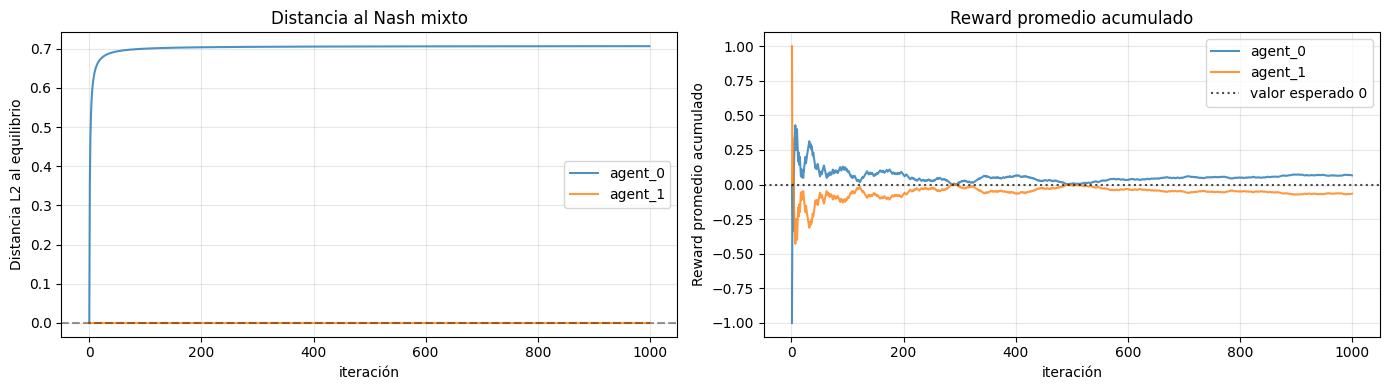

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_rm_random, nash=NASH, max_iter=MAX_ITER,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_rm_random, expected_value=0, max_iter=MAX_ITER,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('mp/distance_and_reward_rm_vs_random')
plt.show()

### Regrets acumulados

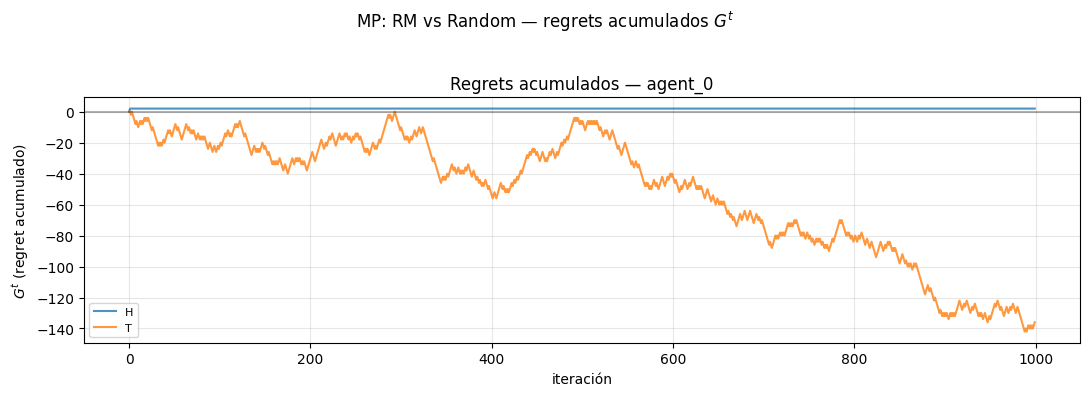

In [8]:
plot_cumulative_regret(history_rm_random, action_labels=LABELS,
                        title='MP: RM vs Random — regrets acumulados $G^t$',
                        save='mp/cum_regrets_rm_vs_random', max_iter=MAX_ITER)
plt.show()

### Regret promedio positivo / t

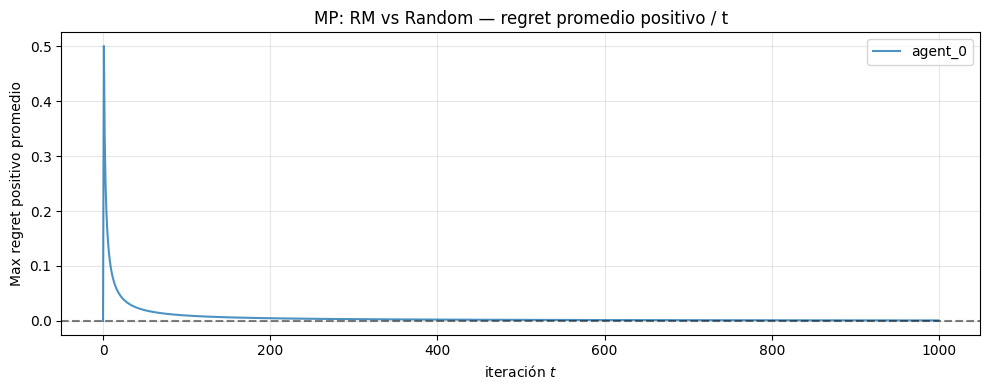

In [9]:
plot_average_positive_regret(history_rm_random,
                              title='MP: RM vs Random — regret promedio positivo / t',
                              save='mp/avg_positive_regret_rm_vs_random', max_iter=MAX_ITER)
plt.show()

### RM: política instantánea vs promedio temporal

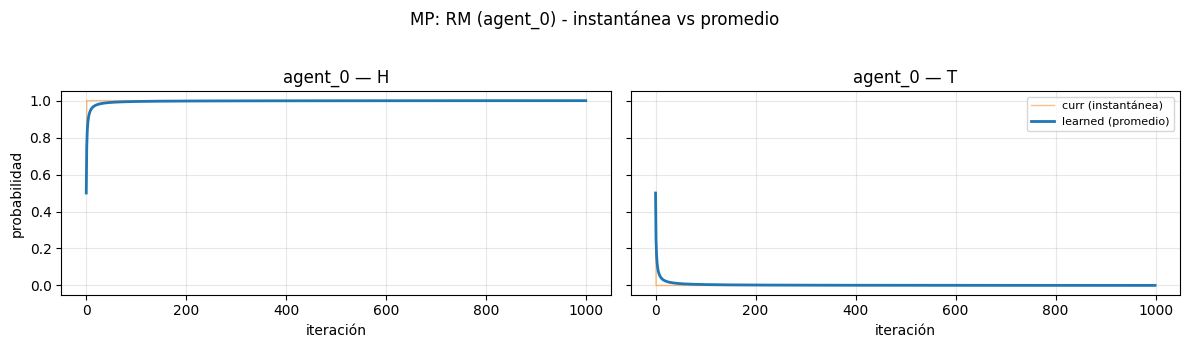

In [10]:
plot_instantaneous_vs_average_policy(history_rm_random, action_labels=LABELS,
                                       agent='agent_0',
                                       title='MP: RM (agent_0) - instantánea vs promedio',
                                       save='mp/curr_vs_avg_policy_rm_in_rm_vs_random', max_iter=MAX_ITER)
plt.show()

---

**Notas**:

- Los `history` dicts quedan persistidos en `data/mp/mp_history_*.pkl`. Por defecto `exp.cached_run` re-ejecuta y sobrescribe (`force=True`); pasar `force=False` para reutilizar el cache cuando el experimento no cambió.
- Las figuras se guardan en `images/mp/*.png`.
- El progreso del experimento queda en `logs/mp/MP.log`.